In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

#Загрузка и первичный анализ данных

data_file = "set.xlsx"

try:
    df = pd.read_excel(data_file)
except Exception as e:
    print("Ошибка загрузки файла: ", e)
    exit(1)


In [17]:
#Генерация синтетических данных (бутстрэппинг с добавлением шума)

def generate_synthetic_bootstrap(data, n_samples, noise_factor=0.05, random_state=42):
    np.random.seed(random_state)
    synthetic_samples = []
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    for _ in range(n_samples):
        sample = data.sample(n=1, replace=True).iloc[0].copy()
        for col in numeric_columns:
            std_dev = data[col].std()
            if pd.isna(std_dev) or std_dev == 0:
                continue
            noise = np.random.normal(loc=0, scale=noise_factor * std_dev)
            sample[col] = sample[col] + noise
        synthetic_samples.append(sample)
    synthetic_df = pd.DataFrame(synthetic_samples)
    return synthetic_df

#Увеличим выборку в 10 раз, так как данных у нас собралось немного
n_original = df.shape[0]
n_synthetic = n_original * 10
synthetic_df = generate_synthetic_bootstrap(df, n_samples=n_synthetic, noise_factor=0.05)
print("\nПервые 5 строк синтетических данных:")
print(synthetic_df.head())

#Объединяем исходные и синтетические данные
extended_df = pd.concat([df, synthetic_df], ignore_index=True)
# print("\nРазмер объединенного датасета:", extended_df.shape)



Первые 5 строк синтетических данных:
              ID  sex        age lifestyle         salary  \
38  2.009508e+09  Жен  20.190284    active   13663.589310   
18  1.996169e+09  Муж  26.657102    medium  176892.210466   
2   1.996020e+09  Муж  20.200299    active  148373.073559   
11  1.996124e+09  Муж  19.842070    medium  248132.941794   
15  1.996118e+09  Жен  19.939505    active   15817.030402   

                                  city  official_difference  
38  Новосибирск, Новосибирская область         -7417.078858  
18                              Москва         -5862.848125  
2                               Москва         -7804.369280  
11                              Москва         -7149.637573  
15                              Москва         -5353.370102  


In [18]:
#Формирование итогового датасета с выбранными признаками

required_columns = ['sex', 'age', 'salary', 'city', 'lifestyle', 'official_difference']

# Проверим, все ли нужные столбцы присутствуют
for col in required_columns:
    if col not in extended_df.columns:
        exit(1)

data_model = extended_df[required_columns].copy()

In [19]:
#Кодирование категориальных признаков
# Обработка столбца "sex"
if 'sex' in data_model.columns:
    data_model['sex'] = data_model['sex'].astype(str)
    # 1 для "муж", 0 для "жен"
    data_model['sex_binary'] = data_model['sex'].apply(lambda x: 1 if x.strip().lower() in ['муж', 'male'] else 0)
    # Убираем исходный столбец
    data_model = data_model.drop(columns=['sex'])

# Кодируем категориальные переменные: "city" и "lifestyle"
data_model = pd.get_dummies(data_model, columns=['city', 'lifestyle'], drop_first=True)


In [20]:
#Подготовка данных для обучения

target_column = "official_difference"
if target_column not in data_model.columns:
    print(f"Ошибка: столбец целевой переменной '{target_column}' отсутствует!")
    exit(1)

X = data_model.drop(columns=[target_column])
y = data_model[target_column]

# Разбиваем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#Построение Pipeline и GridSearchCV

# Создаем Pipeline: стандартная масштабировка, полиномиальное расширение, Ridge-регрессия
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

# Подбираем оптимальную степень полинома и значение alpha
param_grid = {
    'poly__degree': [2, 3],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\nЛучшая комбинация параметров:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# Оценка на тестовой выборке
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nОценка лучшей модели:\nMSE: {mse:.4f}\nR²: {r2:.4f}")

#Задампим нашу лучшую на свете модель

joblib.dump(best_model, "best_model.pkl")



Лучшая комбинация параметров:
{'poly__degree': 3, 'ridge__alpha': 0.01}

Оценка лучшей модели:
MSE: 157666.4136
R²: 0.9107


['best_model.pkl']

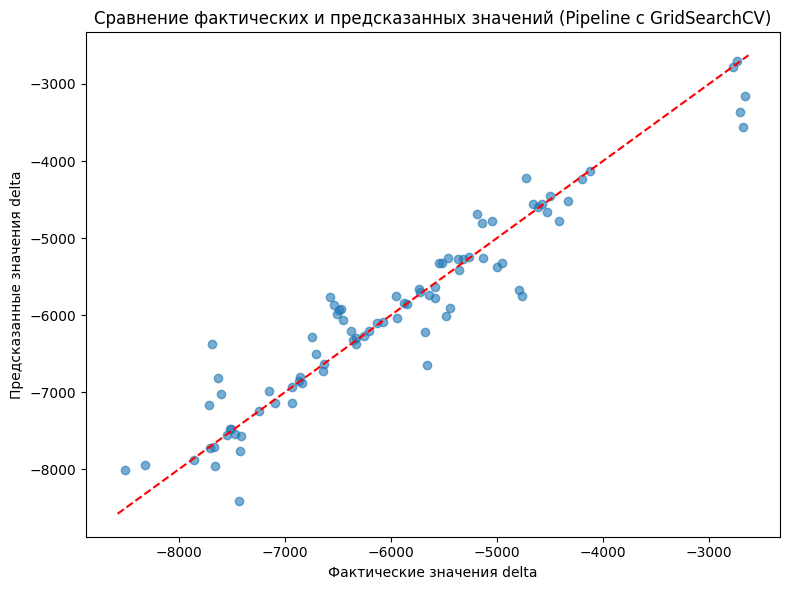

In [ ]:
# Визуализация результатов

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Фактические значения difference")
plt.ylabel("Предсказанные значения difference")
plt.title("Сравнение фактических и предсказанных значений (Pipeline с GridSearchCV)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.tight_layout()
plt.show()

In [23]:
#Пример использования модели для нового наблюдения

import joblib
import pandas as pd

# Загружаем обученную модель (Pipeline), которая включает все преобразования.
model = joblib.load("best_model.pkl")

feature_list = model.feature_names_in_

# Создаем словарь с ключами, равными всем признакам, и устанавливаем начальное значение 0 для каждого признака
input_features = {feature: 0 for feature in feature_list}

# Задаем входные данные для примера 
input_features['age'] = 21
input_features['salary'] = 180000
input_features['sex_binary'] = 0
if 'city_Москва' in input_features:
    input_features['city_Москва'] = 1  # устанавливаем, что город – Москва
if 'lifestyle_active' in input_features:
    input_features['lifestyle_active'] = 1  # стиль жизни active

# Формируем DataFrame для нового наблюдения, обязательно с колонками в том же порядке, что и в модели
new_observation = pd.DataFrame([input_features], columns=feature_list)

# Предсказываем значение (все преобразования внутри Pipeline выполняются автоматически)
prediction = model.predict(new_observation)[0]

print("Прогноз для нового наблюдения (official_difference):", prediction)


Прогноз для нового наблюдения (official_difference): -3621.8539063710587
